# Dados

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
x1 = np.random.rand(1000, 1)
x2 = np.random.rand(1000, 1)
y = x1 + x2 + np.random.rand(1000, 1)

In [16]:
x1.shape, x2.shape, y.shape

((1000, 1), (1000, 1), (1000, 1))

In [18]:
print(f"Primeiras 5 linhas (Feature 1): \n{x1[:5]}\n")
print(f"Primeiras 5 linhas (Feature 2): \n{x2[:5]}\n")
print(f"Primeiras 5 linhas (Targets): \n{y[:5]}")

Primeiras 5 linhas (Feature 1): 
[[0.18372126]
 [0.09613486]
 [0.56964914]
 [0.21203287]
 [0.83240402]]

Primeiras 5 linhas (Feature 2): 
[[0.9327694 ]
 [0.7673994 ]
 [0.00101027]
 [0.93051688]
 [0.41940465]]

Primeiras 5 linhas (Targets): 
[[1.97512897]
 [1.34646721]
 [1.54217022]
 [1.79687341]
 [2.20965848]]


# Visualizando

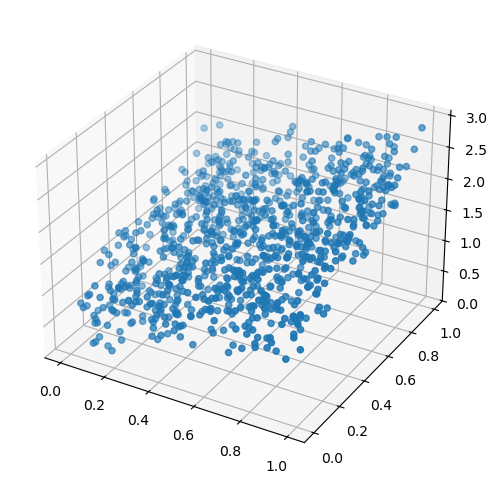

In [25]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter3D(x1, x2, y)
plt.show()

# Modelo

In [26]:
X = np.hstack((x1, x2))

In [27]:
def f_x(X, w, b):
    y_hat = np.dot(X, w) + b
    return y_hat

In [29]:
def compute_cost(X, y, w, b): 
    m = X.shape[0]
    y_hat = f_x(X, w, b)
    errors = y_hat - y

    cost = (1 / (2 * m)) * np.sum(errors ** 2)
    return cost

In [113]:
def calculate_gradient(X, y, w, b):
    m = X.shape[0]
    y_hat = f_x(X, w, b)
    errors = y_hat - y

    w_gradient = (1 / m) * np.dot(np.transpose(X), errors)
    b_gradient = np.mean(errors)

    return w_gradient, b_gradient

In [114]:
def gradient_descent(X, y, alpha=0.01, num_iters=5000, hist_interval=100):
    history = {}
    n = X.shape[1]
    w = np.zeros((n, 1))
    b = 0
    
    for iters in range(num_iters):
        w_gradient, b_gradient = calculate_gradient(X, y, w, b)
        w = w - (alpha * w_gradient)
        b = b - (alpha * b_gradient)

        if iters % hist_interval == 0:
            cost = compute_cost(X, y, w, b)
            history[iters] = cost
            print(f"Iteraction: {iters} \t Cost: {cost}")
    return history, w, b

In [145]:
class MultipleRegression():
    def __init__(self):
        self.w = []
        self.b = 0
    
    def fit(self, X, y, num_i):
        _, self.w, self.b= gradient_descent(X, y, hist_interval=1000, num_iters=num_i)
        return self.w, self.b
    
    def predict(self, X):
        y_hat = f_x(X, self.w, self.b)
        return y_hat

In [146]:
model = MultipleRegression()

In [168]:
w, b = model.fit(X, y, num_i=20000)

Iteraction: 0 	 Cost: 1.204610771471464
Iteraction: 1000 	 Cost: 0.04660184045279335
Iteraction: 2000 	 Cost: 0.042994236664078575
Iteraction: 3000 	 Cost: 0.04172555047009014
Iteraction: 4000 	 Cost: 0.04127937928569463
Iteraction: 5000 	 Cost: 0.04112246761989738
Iteraction: 6000 	 Cost: 0.04106728371948172
Iteraction: 7000 	 Cost: 0.041047876138556365
Iteraction: 8000 	 Cost: 0.04104105068660485
Iteraction: 9000 	 Cost: 0.0410386502405151
Iteraction: 10000 	 Cost: 0.04103780602605327
Iteraction: 11000 	 Cost: 0.04103750912360904
Iteraction: 12000 	 Cost: 0.04103740470573629
Iteraction: 13000 	 Cost: 0.041037367982922165
Iteraction: 14000 	 Cost: 0.04103735506784243
Iteraction: 15000 	 Cost: 0.04103735052572623
Iteraction: 16000 	 Cost: 0.041037348928305184
Iteraction: 17000 	 Cost: 0.04103734836650671
Iteraction: 18000 	 Cost: 0.04103734816892728
Iteraction: 19000 	 Cost: 0.041037348099440395


In [169]:
predict = model.predict(X)

In [170]:
predict.shape, X.shape

((1000, 1), (1000, 2))

# Visualizando a Regressão

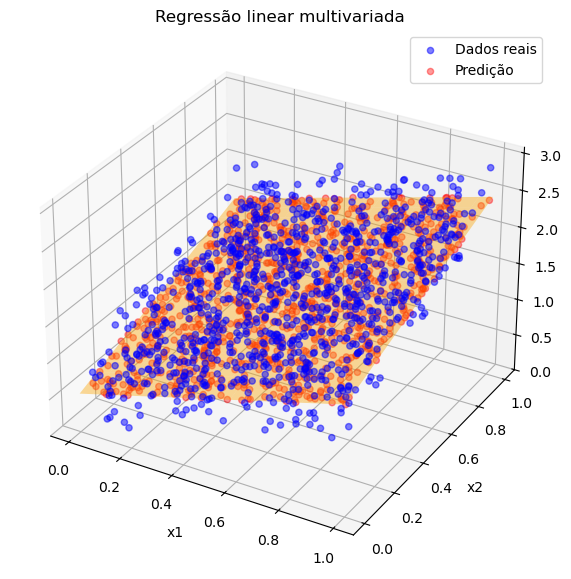

In [171]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter3D(x1, x2, y, color='blue', label='Dados reais', alpha=0.5)
ax.scatter3D(x1, x2, predict, color='red', label='Predição', alpha=0.4)

x1_grid, x2_grid = np.meshgrid(
    np.linspace(x1.min(), x1.max(), 20),
    np.linspace(x2.min(), x2.max(), 20)
)
X_grid = np.c_[x1_grid.ravel(), x2_grid.ravel()]
y_grid = model.predict(X_grid).reshape(x1_grid.shape)

ax.plot_surface(x1_grid, x2_grid, y_grid, color='orange', alpha=0.4, edgecolor='none')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('y')
ax.legend()
plt.title('Regressão linear multivariada')
plt.show()

# Comparando com `scikit-learn`

In [172]:
from sklearn.linear_model import LinearRegression

In [173]:
lib_model = LinearRegression()

In [174]:
lib_model.fit(X, y)

LinearRegression()

In [175]:
w_lib, b_lib = lib_model.coef_, lib_model.intercept_

In [178]:
print(f'My Model: \n Coefficents: \n{w} \n Intercept: {b}')
print('---------------------------------------------------')
print(f'SK Learn: \n Coefficents: {w_lib} \n Intercept: {b_lib}')

My Model: 
 Coefficents: 
[[0.97693458]
 [0.95843104]] 
 Intercept: 0.530189939333813
---------------------------------------------------
SK Learn: 
 Coefficents: [[0.97694764 0.95844351]] 
 Intercept: [0.53017644]
